In [2]:
import os
import sys

# Move up one level from 'notebooks/' to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# FIX: Changed 'load_initialize_data' to 'load_insurance_data'
from src.data_loader import load_insurance_data
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# FIX: Call the correct function name here too
df = load_insurance_data('../data/insurance_data.csv')

# 1. Total Portfolio Loss Ratio
total_claims = df['TotalClaims'].sum()
total_premium = df['TotalPremium'].sum()
portfolio_loss_ratio = total_claims / total_premium
print(f"Global Portfolio Loss Ratio: {portfolio_loss_ratio:.2%}")

Global Portfolio Loss Ratio: 52.82%


In [3]:
# Group by Province
province_stats = df.groupby('Province').agg(
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum')
).reset_index()
province_stats['LossRatio'] = province_stats['TotalClaims'] / province_stats['TotalPremium']
print(province_stats.sort_values(by='LossRatio', ascending=False))

# Group by Gender
gender_stats = df.groupby('Gender').agg(
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum')
).reset_index()
gender_stats['LossRatio'] = gender_stats['TotalClaims'] / gender_stats['TotalPremium']
print(gender_stats)

      Province  TotalPremium  TotalClaims  LossRatio
3       Somali       2984984    1826593.0   0.611927
2       Oromia       6069663    3261061.0   0.537272
4       Tigray       1990692    1047136.0   0.526016
0  Addis Ababa       8907374    4653210.0   0.522400
1       Amhara       4928566    2353885.0   0.477600
   Gender  TotalPremium  TotalClaims  LossRatio
0  Female      12791141    6763030.0   0.528728
1    Male      12090138    6378855.0   0.527608


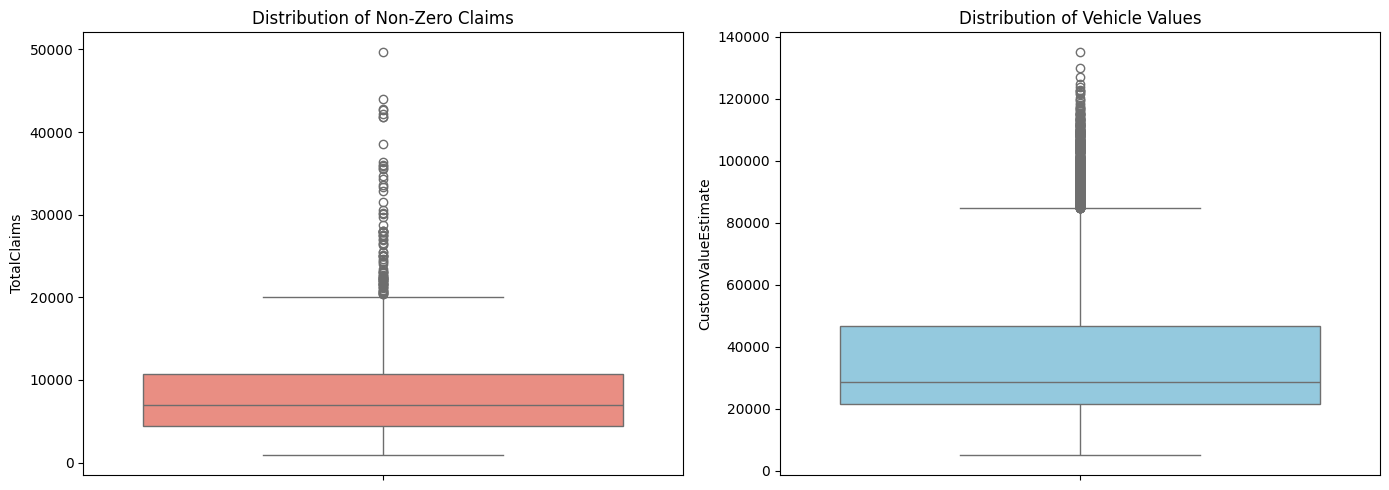

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot for Claims
sns.boxplot(data=df[df['TotalClaims'] > 0], y='TotalClaims', ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Non-Zero Claims')

# Boxplot for Vehicle Values
sns.boxplot(data=df, y='CustomValueEstimate', ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Vehicle Values')

plt.tight_layout()
plt.show()

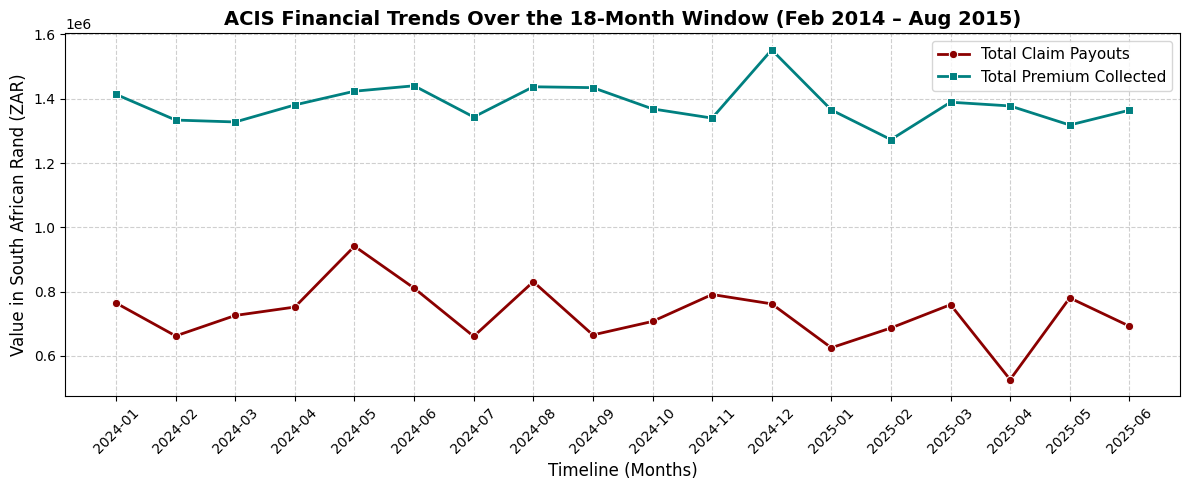

In [5]:
# 1. Ensure TransactionDate is a datetime object
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# 2. Create a clean Year-Month column for grouping
df['TransactionMonth'] = df['TransactionDate'].dt.to_period('M')

# 3. Aggregate metrics by month
temporal_df = df.groupby('TransactionMonth').agg(
    MonthlyClaims=('TotalClaims', 'sum'),
    MonthlyPremium=('TotalPremium', 'sum'),
    ClaimCount=('TotalClaims', lambda x: (x > 0).sum())
).reset_index()

# 4. Convert Period back to string format so matplotlib can plot it smoothly
temporal_df['TransactionMonth'] = temporal_df['TransactionMonth'].astype(str)

# 5. Plot the trend line
plt.figure(figsize=(12, 5))
sns.lineplot(data=temporal_df, x='TransactionMonth', y='MonthlyClaims', marker='o', color='darkred', linewidth=2, label='Total Claim Payouts')
sns.lineplot(data=temporal_df, x='TransactionMonth', y='MonthlyPremium', marker='s', color='teal', linewidth=2, label='Total Premium Collected')

plt.title('ACIS Financial Trends Over the 18-Month Window (Feb 2014 – Aug 2015)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('Value in South African Rand (ZAR)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
# Load the raw data that DVC is tracking
df = pd.read_csv('../data/insurance_data.csv')

# Apply baseline data-cleaning fixes
df['TotalClaims'] = df['TotalClaims'].fillna(0)
df['TotalPremium'] = df['TotalPremium'].fillna(0)

# Drop any rows completely missing critical demographic metrics
df_cleaned = df.dropna(subset=['Gender', 'Province', 'VehicleType'])

# Save this out as your second data version
df_cleaned.to_csv('../data/cleaned_insurance_data.csv', index=False)
print("Cleaned dataset version generated successfully!")

Cleaned dataset version generated successfully!
